# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** [Nama Lu]
- **Email:** [Email Lu]
- **ID Dicoding:** [ID Lu]

## Menentukan Pertanyaan Bisnis
- Jam berapa penyewaan sepeda paling tinggi dan paling rendah dalam sehari?
- Pada bulan apa penyewaan sepeda mencapai puncaknya?

## Import Semua Packages/Library yang Digunakan

In [4]:
# Import library standar untuk manipulasi data dan visualisasi
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling
### Gathering Data

In [5]:
# Memuat dataset harian dan per jam (Pastikan path folder benar)
days_df = pd.read_csv("data/day.csv")
hours_df = pd.read_csv("data/hour.csv")

# Membuktikan data berhasil dimuat dengan menampilkan 5 baris pertama
display("Data Harian (days_df):", days_df.head())
display("Data Per Jam (hours_df):", hours_df.head())

'Data Harian (days_df):'

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


'Data Per Jam (hours_df):'

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Assessing Data

In [9]:
# Mengecek informasi tipe data dan jumlah missing value
print("INFO DATA HARIAN:")
days_df.info()


INFO DATA HARIAN:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [11]:
print("\nINFO DATA PER JAM:")
hours_df.info()



INFO DATA PER JAM:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [13]:
# Mengecek jumlah duplikasi data
print("Jumlah duplikasi pada days_df:", days_df.duplicated().sum())
print("Jumlah duplikasi pada hours_df:", hours_df.duplicated().sum())


Jumlah duplikasi pada days_df: 0
Jumlah duplikasi pada hours_df: 0


In [14]:
# Mengecek nilai statistik deskriptif
display("Ringkasan Statistik Data Harian:", days_df.describe())

'Ringkasan Statistik Data Harian:'

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


### Cleaning Data

In [15]:
# Mengubah tipe data kolom tanggal (dteday) menjadi format datetime yang benar
days_df['dteday'] = pd.to_datetime(days_df['dteday'])
hours_df['dteday'] = pd.to_datetime(hours_df['dteday'])

# Membuktikan tipe data sudah berubah
print("Tipe data dteday pada days_df sekarang:", days_df['dteday'].dtype)
print("Tipe data dteday pada hours_df sekarang:", hours_df['dteday'].dtype)

Tipe data dteday pada days_df sekarang: datetime64[ns]
Tipe data dteday pada hours_df sekarang: datetime64[ns]


## Exploratory Data Analysis (EDA)

In [16]:
# Melakukan eksplorasi total penyewaan berdasarkan nama hari
weekday_map = {0: 'Minggu', 1: 'Senin', 2: 'Selasa', 3: 'Rabu', 4: 'Kamis', 5: 'Jumat', 6: 'Sabtu'}
weekday_totals = days_df.groupby('weekday')['cnt'].sum()
weekday_totals.index = weekday_totals.index.map(weekday_map)

print("Total penyewaan sepeda berdasarkan nama hari:")
display(weekday_totals)

Total penyewaan sepeda berdasarkan nama hari:


weekday
Minggu    444027
Senin     455503
Selasa    469109
Rabu      473048
Kamis     485395
Jumat     487790
Sabtu     477807
Name: cnt, dtype: int64

### Advanced Analysis: Clustering (Manual Grouping & Binning)
Tahapan ini ditambahkan untuk memenuhi kriteria analisis lanjutan sesuai rubrik penilaian.

In [18]:
# 1. Manual Grouping: Mengelompokkan waktu operasional menjadi Pagi, Siang, Sore, dan Malam
def waktu_kelompok(jam):
    if 5 <= jam <= 9: return 'Pagi'
    elif 10 <= jam <= 15: return 'Siang'
    elif 16 <= jam <= 20: return 'Sore/Malam'
    else: return 'Larut Malam'

hours_df['waktu_kelompok'] = hours_df['hr'].apply(waktu_kelompok)
waktu_rentals = hours_df.groupby('waktu_kelompok')['cnt'].sum().sort_values(ascending=False)

print("Total penyewaan berdasarkan kelompok waktu:")
display(waktu_rentals)

Total penyewaan berdasarkan kelompok waktu:


waktu_kelompok
Sore/Malam     1265719
Siang          1005711
Pagi            644003
Larut Malam     377246
Name: cnt, dtype: int64

In [19]:
# 2. Binning: Mengkategorikan performa hari penyewaan menjadi Rendah, Sedang, Tinggi
def penyewaan_kelompok(jumlah):
    if jumlah < 500: return 'Rendah'
    elif 500 <= jumlah <= 2000: return 'Sedang'
    else: return 'Tinggi'

days_df['kelompok_penyewaan'] = days_df['cnt'].apply(penyewaan_kelompok)

print("Distribusi kategori performa harian (Binning):")
display(days_df['kelompok_penyewaan'].value_counts())

Distribusi kategori performa harian (Binning):


kelompok_penyewaan
Tinggi    633
Sedang     95
Rendah      3
Name: count, dtype: int64

## Visualization & Explanatory Analysis
### Pertanyaan 1: Jam berapa penyewaan sepeda paling tinggi dan paling rendah dalam sehari?

/tmp/ipykernel_4320/964256703.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_totals.index, y=hourly_totals.values, palette=colors_hour)


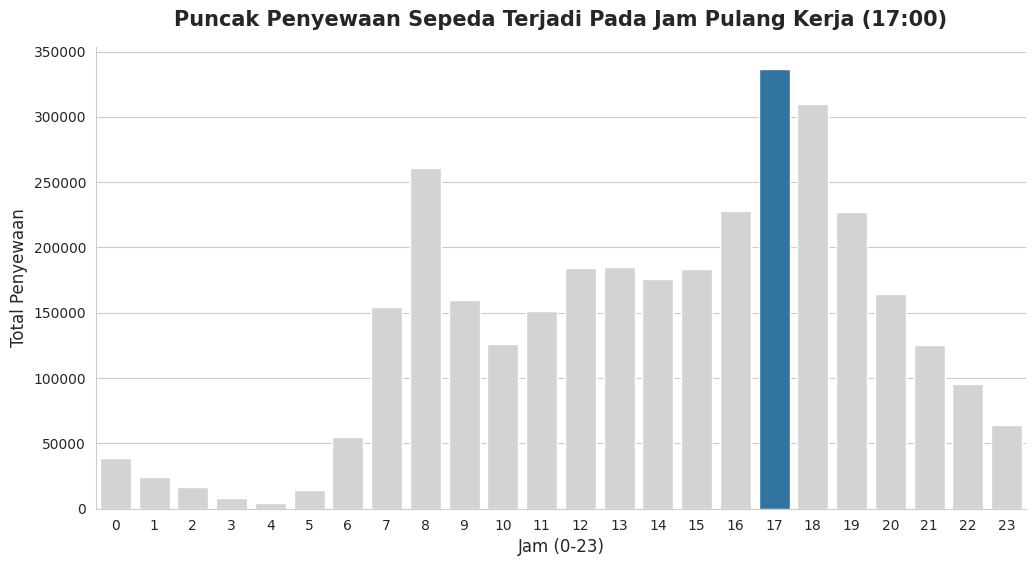

In [20]:
# Menghitung total penyewaan per jam
hourly_totals = hours_df.groupby('hr')['cnt'].sum()
peak_hour = hourly_totals.idxmax()

# Membuat Bar Chart dengan menerapkan McCandless Method (Highlight warna)
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Mewarnai batang puncak dengan biru gelap, sisanya abu-abu
colors_hour = ["#D3D3D3" if x != peak_hour else "#1F77B4" for x in hourly_totals.index]

sns.barplot(x=hourly_totals.index, y=hourly_totals.values, palette=colors_hour)

# Formatting chart
plt.title(f"Puncak Penyewaan Sepeda Terjadi Pada Jam Pulang Kerja ({peak_hour}:00)", loc="center", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Jam (0-23)", fontsize=12)
plt.ylabel("Total Penyewaan", fontsize=12)
sns.despine()

plt.show() # Menampilkan chart

### Pertanyaan 2: Pada bulan apa penyewaan sepeda mencapai puncaknya?

/tmp/ipykernel_4320/219617078.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_totals.index, y=monthly_totals.values, palette=colors_month)


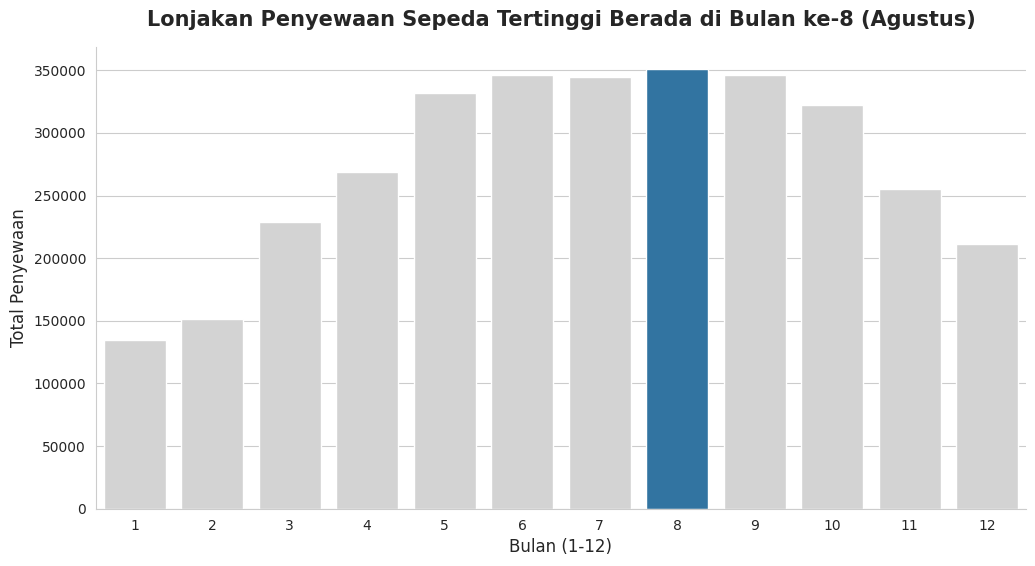

In [21]:
# Menghitung total penyewaan per bulan
monthly_totals = days_df.groupby('mnth')['cnt'].sum()
peak_month = monthly_totals.idxmax()

# Membuat Bar Chart dengan menerapkan McCandless Method (Highlight warna)
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Mewarnai batang puncak dengan biru gelap, sisanya abu-abu
colors_month = ["#D3D3D3" if x != peak_month else "#1F77B4" for x in monthly_totals.index]

sns.barplot(x=monthly_totals.index, y=monthly_totals.values, palette=colors_month)

# Formatting chart
plt.title(f"Lonjakan Penyewaan Sepeda Tertinggi Berada di Bulan ke-{peak_month} (Agustus)", loc="center", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Bulan (1-12)", fontsize=12)
plt.ylabel("Total Penyewaan", fontsize=12)
sns.despine()

plt.show() # Menampilkan chart

## Conclusion
- **Conclusion pertanyaan 1:** Penyewaan sepeda tertinggi terjadi pada pukul 17:00 (jam 5 sore) dengan total lebih dari 336 ribu penyewaan, sedangkan titik terendah ada pada pukul 04:00 dini hari. Pola ini sangat kuat mengindikasikan bahwa sepeda mayoritas digunakan untuk komutasi para pekerja kantoran pada saat jam pulang kerja.
- **Conclusion pertanyaan 2:** Total penyewaan tertinggi terjadi pada bulan ke-8 (Agustus) dengan lebih dari 351 ribu penyewaan, sedangkan paling sepi ada di bulan Januari. Lonjakan di pertengahan tahun ini dipengaruhi oleh faktor musim panas yang hangat, masa liburan, dan kondisi cuaca yang sangat mendukung aktivitas luar ruangan dibandingkan saat musim dingin di awal tahun.